# Compare two custom `H` formats on one plot

This notebook compares block error rate vs physical error rate for:
- **Format A**: `(B+2) x (4B)` (block rows + 2 global rows)
- **Format B**: `(3B) x (4B)` (3 ancillas per 4-data block)

Both are simulated with the same Stim noise model and plotted together.

In [2]:
import numpy as np
import stim
import matplotlib.pyplot as plt

In [3]:
def make_H_plus2(num_blocks: int) -> np.ndarray:
    """Format A: (B+2) x (4B)."""
    if num_blocks <= 0:
        raise ValueError("num_blocks must be >= 1")
    top = np.kron(np.eye(num_blocks, dtype=np.uint8), np.ones((1, 4), dtype=np.uint8))
    r1 = np.tile(np.array([1, 1, 0, 0], dtype=np.uint8), num_blocks)
    r2 = np.tile(np.array([1, 0, 1, 0], dtype=np.uint8), num_blocks)
    return np.vstack([top, r1, r2]).astype(np.uint8)


def make_H_3anc_per_4data(num_blocks: int) -> np.ndarray:
    """Format B: (3B) x (4B)."""
    if num_blocks <= 0:
        raise ValueError("num_blocks must be >= 1")
    H_block = np.array(
        [
            [1, 1, 1, 1],
            [1, 1, 0, 0],
            [1, 0, 1, 0],
        ],
        dtype=np.uint8,
    )
    return np.kron(np.eye(num_blocks, dtype=np.uint8), H_block).astype(np.uint8)

In [4]:
def build_syndrome_circuit_from_H(H: np.ndarray, p_data: float = 0.02, p_meas: float = 0.0) -> stim.Circuit:
    """One-round X-noise memory circuit with Z-check syndrome extraction from H."""
    H = (H % 2).astype(np.uint8)
    m, n = H.shape

    data = list(range(n))
    anc = list(range(n, n + m))

    circuit = stim.Circuit()
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, float(p_data))

    for i in range(m):
        a = anc[i]
        support = [j for j, bit in enumerate(H[i]) if bit]
        circuit.append("H", [a])
        for q in support:
            circuit.append("CZ", [a, q])
        circuit.append("H", [a])
        if p_meas > 0:
            circuit.append("X_ERROR", [a], float(p_meas))
        circuit.append("M", [a])
        circuit.append("DETECTOR", [stim.target_rec(-1)])

    circuit.append("M", data)
    return circuit


def sample_syndrome_dataset(circuit: stim.Circuit, H: np.ndarray, shots: int = 1000):
    m, n = H.shape
    sampler = circuit.compile_sampler()
    meas = sampler.sample(shots=shots).astype(np.uint8)
    syndromes = meas[:, :m]
    data_meas = meas[:, m:m+n]
    return syndromes, data_meas


def build_min_weight_syndrome_lut(H: np.ndarray):
    """Exact min-weight syndrome LUT (feasible for small n, e.g. n=8)."""
    H = (H & 1).astype(np.uint8)
    m, n = H.shape
    lut = {}
    for mask in range(1 << n):
        e = np.fromiter(((mask >> j) & 1 for j in range(n)), dtype=np.uint8, count=n)
        syn = tuple(((H @ e) & 1).tolist())
        w = int(mask.bit_count())
        if syn not in lut or w < lut[syn][0]:
            lut[syn] = (w, e.copy())
    return {k: v[1] for k, v in lut.items()}


def decode_batch(syndromes: np.ndarray, lut: dict, n: int) -> np.ndarray:
    out = np.zeros((len(syndromes), n), dtype=np.uint8)
    for i, s in enumerate(syndromes):
        out[i] = lut.get(tuple((s & 1).tolist()), np.zeros(n, dtype=np.uint8))
    return out


def evaluate_block_error_rate(H: np.ndarray, p_data: float, p_meas: float, shots: int, lut: dict):
    circuit = build_syndrome_circuit_from_H(H, p_data=p_data, p_meas=p_meas)
    syndromes, data_meas = sample_syndrome_dataset(circuit, H, shots=shots)
    e_hat = decode_batch(syndromes, lut=lut, n=H.shape[1])
    fails = np.any((e_hat ^ data_meas) != 0, axis=1)
    return float(np.mean(fails))

Format A shape: (6, 16) (B+2 x 4B)
[[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]]

Format B shape: (12, 16) (3B x 4B)
[[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]]
p=0.2 | Format A=0.805350 | Format B=0.356180
p=0.1 | Format A=0.421075 | Format B=0.107310
p=0.05 | Format A=0.154770 | Format B=0.028990
p=0.02 | Format A=0.031945 | Format B=0.005075
p=0.01 | Format A=0.008940 | Format B=0.001170
p=0.005 | Format A=0.002065 | Format B=0.000305
p=0.002 | Format

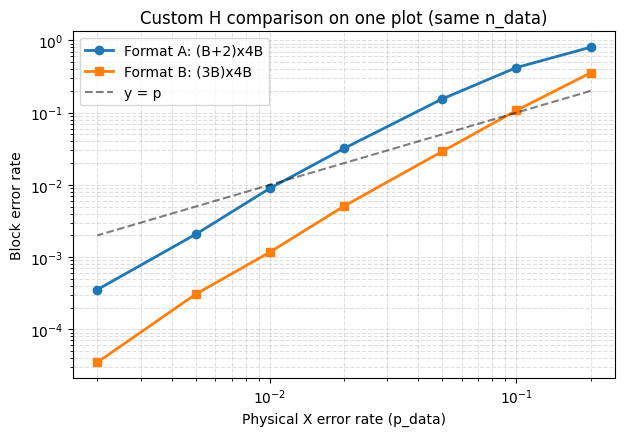

In [5]:
# --- Comparison run: same n_data for both H formats, single plot ---
num_blocks = 4  # keeps both matrices small (n_data = 8)
p_meas = 0.0
shots = 200_000
p_data_values = np.array([0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002], dtype=float)

H_a = make_H_plus2(num_blocks)
H_b = make_H_3anc_per_4data(num_blocks)

print("Format A shape:", H_a.shape, "(B+2 x 4B)")
print(H_a)
print("\nFormat B shape:", H_b.shape, "(3B x 4B)")
print(H_b)

lut_a = build_min_weight_syndrome_lut(H_a)
lut_b = build_min_weight_syndrome_lut(H_b)

err_a = []
err_b = []

for p in p_data_values:
    e_a = evaluate_block_error_rate(H_a, p_data=float(p), p_meas=p_meas, shots=shots, lut=lut_a)
    e_b = evaluate_block_error_rate(H_b, p_data=float(p), p_meas=p_meas, shots=shots, lut=lut_b)
    err_a.append(e_a)
    err_b.append(e_b)
    print(f"p={p:.4g} | Format A={e_a:.6f} | Format B={e_b:.6f}")

plt.figure(figsize=(7, 4.5))
plt.loglog(p_data_values, err_a, marker="o", linewidth=2, label="Format A: (B+2)x4B")
plt.loglog(p_data_values, err_b, marker="s", linewidth=2, label="Format B: (3B)x4B")
plt.loglog(p_data_values, p_data_values, "k--", alpha=0.5, label="y = p")
plt.xlabel("Physical X error rate (p_data)")
plt.ylabel("Block error rate")
plt.title("Custom H comparison on one plot (same n_data)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

In [21]:
import sinter

def generate_rep_code_bit_flips(d, noise):
    # SOLUTION ===
    circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=3*d,
    distance=d,
    before_measure_flip_probability=noise)
    # ===
    return circuit

tasks = [
    sinter.Task(
        circuit=generate_rep_code_bit_flips(d, noise),
        json_metadata={'d': d, 'p': noise},
    )
    for d in [3, 5, 7, 9]
    for noise in [ 0.05, 0.08, 0.1, 0.2, 0.3]
]

collected_stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=1_000_00,
    max_errors=300,
)

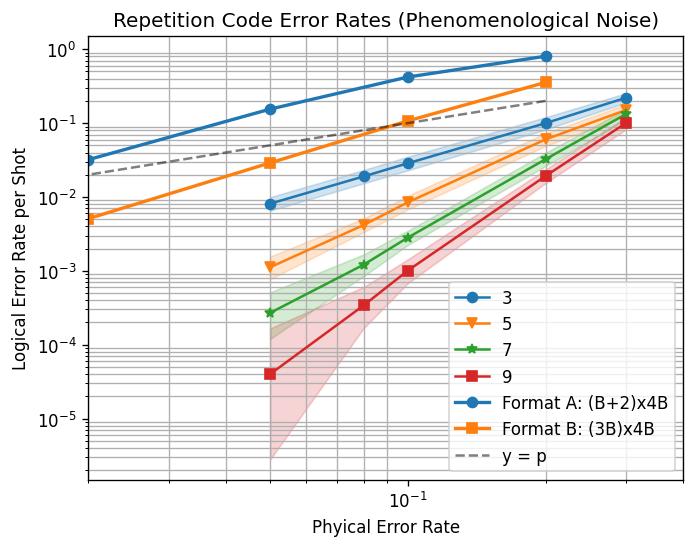

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
# ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(2e-2, 4e-1)
ax.loglog(p_data_values, err_a, marker="o", linewidth=2, label="Format A: (B+2)x4B")
ax.loglog(p_data_values, err_b, marker="s", linewidth=2, label="Format B: (3B)x4B")
ax.loglog(p_data_values, p_data_values, "k--", alpha=0.5, label="y = p")
ax.set_title("Repetition Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
# ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
# Compare code rate k/n using:
# - theoretical formulas from each H format
# - actual rank over GF(2) from H_a, H_b

def gf2_rank(H: np.ndarray) -> int:
    A = (H.copy() & 1).astype(np.uint8)
    m, n = A.shape
    r = 0
    for c in range(n):
        if r >= m:
            break
        piv = np.where(A[r:, c] == 1)[0]
        if len(piv) == 0:
            continue
        p = r + piv[0]
        if p != r:
            A[[r, p]] = A[[p, r]]
        for i in range(m):
            if i != r and A[i, c]:
                A[i] ^= A[r]
        r += 1
    return r

B = num_blocks if "num_blocks" in globals() else (H_a.shape[1] // 4)

def rate_a_theory(B: int) -> float:
    # Format A: H is (B+2) x (4B), rank ~ (B+2)
    return (3 * B - 2) / (4 * B)

def rate_b_theory(B: int) -> float:
    # Format B: H is (3B) x (4B), rank ~ (3B)
    return 1 / 4

rows = []
for name, H, r_th in [
    ("Format A (B+2)x(4B)", H_a, rate_a_theory(B)),
    ("Format B (3B)x(4B)", H_b, rate_b_theory(B)),
]:
    m, n = H.shape
    r = gf2_rank(H)
    k = n - r
    rate_emp = k / n
    rows.append((name, n, m, r, k, rate_emp, r_th, rate_emp - r_th))

    def make_rep_H(distance: int) -> np.ndarray:
        H_rep = np.zeros((distance - 1, distance), dtype=np.uint8)
        for i in range(distance - 1):
            H_rep[i, i] = 1
            H_rep[i, i + 1] = 1
        return H_rep

    rep_distances = sorted({int(t.json_metadata["d"]) for t in tasks}) if "tasks" in globals() else [3, 5, 7, 9]

    for d_rep in rep_distances:
        H_rep = make_rep_H(d_rep)
        m_rep, n_rep = H_rep.shape
        r_rep = gf2_rank(H_rep)
        k_rep = n_rep - r_rep
        rate_emp_rep = k_rep / n_rep
        rate_th_rep = 1 / d_rep
        rows.append((
            f"Repetition d={d_rep}",
            n_rep,
            m_rep,
            r_rep,
            k_rep,
            rate_emp_rep,
            rate_th_rep,
            rate_emp_rep - rate_th_rep,
        ))

rows.sort(key=lambda row: -row[5])
rows = rows.unique()


print(f"B = {B}")
print(f"{'Format':24s} {'n':>4s} {'m':>4s} {'k':>4s} {'rate=k/n':>10s}")
print("-" * 56)
for name, n, m, r, k, rate_emp, r_th, d in rows:
    print(f"{name:24s} {n:4d} {m:4d} {k:4d} {rate_emp:10.6f}")

def estimate_threshold_p(p_vals, pL_vals):
    """Estimate p* where pL(p*) = p using log-log interpolation."""
    p = np.asarray(p_vals, dtype=float)
    pL = np.asarray(pL_vals, dtype=float)

    order = np.argsort(p)
    p = p[order]
    pL = pL[order]

    g = np.log(pL) - np.log(p)  # zero when pL = p

    # Exact hit on sampled points
    hit = np.where(np.isclose(g, 0.0))[0]
    if len(hit):
        return float(p[hit[0]])

    # Bracketed crossing
    for i in range(len(p) - 1):
        if g[i] * g[i + 1] < 0:
            t = -g[i] / (g[i + 1] - g[i])  # linear interpolation in log space
            return float(np.exp(np.log(p[i]) + t * (np.log(p[i + 1]) - np.log(p[i]))))

    return np.nan  # no crossing in scanned range

thr_a = estimate_threshold_p(p_data_values, err_a)
thr_b = estimate_threshold_p(p_data_values, err_b)

print("\nEstimated thresholds (pL = p):")
print(f"Format A: {thr_a:.6g}" if np.isfinite(thr_a) else "Format A: no crossing in scanned p range")
print(f"Format B: {thr_b:.6g}" if np.isfinite(thr_b) else "Format B: no crossing in scanned p range")

B = 4
Format                      n    m    k   rate=k/n
--------------------------------------------------------
Format A (B+2)x(4B)        16    6   10   0.625000
Repetition d=3              3    2    1   0.333333
Repetition d=3              3    2    1   0.333333
Format B (3B)x(4B)         16   12    4   0.250000
Repetition d=5              5    4    1   0.200000
Repetition d=5              5    4    1   0.200000
Repetition d=7              7    6    1   0.142857
Repetition d=7              7    6    1   0.142857
Repetition d=9              9    8    1   0.111111
Repetition d=9              9    8    1   0.111111

Estimated thresholds (pL = p):
Format A: 0.011432
Format B: 0.0923637
